In [2]:
!pip install pandas matplotlib statsmodels



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()


In [12]:
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv")
df.columns = ['Date', 'Sales']
# Prepend '190' to the year part to make it '1901-01', '1901-02', etc.
df['Date'] = pd.to_datetime('200' + df['Date'], format='%Y-%m')
df.set_index('Date', inplace=True)
df

,Sales
Date,
2001-01-01,266.0
2001-02-01,145.9
2001-03-01,183.1
2001-04-01,119.3
2001-05-01,180.3
2001-06-01,168.5
2001-07-01,231.8
2001-08-01,224.5
2001-09-01,192.8


In [13]:
# Simulated monthly sales data
dates = pd.date_range(start='2020-01-01', periods=36, freq='M')
sales = [200, 220, 210, 215, 225, 240, 250, 245, 260, 275, 270, 290,
         300, 310, 320, 330, 340, 350, 360, 355, 370, 380, 400, 390,
         410, 430, 420, 440, 450, 470, 460, 480, 490, 510, 500, 520]

df = pd.DataFrame({'Date': dates, 'Sales': sales})
df.set_index('Date', inplace=True)
print(df.head())


            Sales
Date             
2020-01-31    200
2020-02-29    220
2020-03-31    210
2020-04-30    215
2020-05-31    225


C:\Users\usamawahabkhan\AppData\Local\Temp\ipykernel_6544\1403201882.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2020-01-01', periods=36, freq='M')


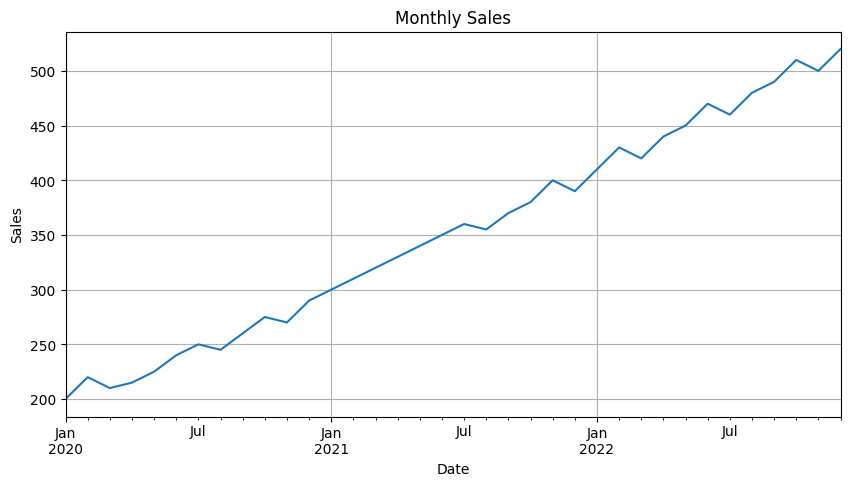

In [14]:
df['Sales'].plot(figsize=(10, 5), title='Monthly Sales')
plt.ylabel('Sales')
plt.grid(True)
plt.show()


### 🔹 Step 5: Check for Stationarity (Optional)

In this step, we use the Augmented Dickey-Fuller (ADF) test to check if the time series data is **stationary**. Stationarity means that the statistical properties of the series (like mean and variance) do not change over time, which is an important assumption for ARIMA modeling.

**Code Explanation:**
```python
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Sales'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
```

- `adfuller(df['Sales'])`: Runs the ADF test on the sales data.
- `result[0]`: The ADF test statistic. More negative values indicate stronger evidence against non-stationarity.
- `result[1]`: The p-value. If this is less than 0.05, we can reject the null hypothesis and conclude the series is stationary.

**Why is this important?**  
ARIMA models require the input series to be stationary. If the series is not stationary, we may need to difference the data or apply transformations before modeling.

**Summary:**  
This cell helps determine if the sales data is suitable for ARIMA modeling by testing for stationarity.

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Sales'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])


## ARIMA Model and Forecasting Explained

The cell below fits an ARIMA model to the monthly sales data and prints a summary of the fitted model:

```python
# ARIMA(p, d, q): we’ll try (1,1,1)
model = ARIMA(df['Sales'], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())
```

### What is ARIMA?

**ARIMA** stands for **AutoRegressive Integrated Moving Average**. It is a popular statistical method for time series forecasting. The model is defined by three parameters:

- **p**: Number of autoregressive (AR) terms. This represents the relationship between an observation and a number of lagged observations.
- **d**: Number of differences needed to make the series stationary (Integrated part).
- **q**: Number of lagged forecast errors in the prediction equation (Moving Average part).

In this notebook, we use `order=(1, 1, 1)`, which means:
- 1 AR term,
- 1 differencing step,
- 1 MA term.

### What does the code do?

1. **model = ARIMA(df['Sales'], order=(1, 1, 1))**  
    This creates an ARIMA model object using the sales data.

2. **model_fit = model.fit()**  
    This fits the ARIMA model to the data, estimating the best parameters.

3. **print(model_fit.summary())**  
    This prints a detailed summary of the fitted model, including coefficients, statistical significance, and diagnostics.

### Why use ARIMA?

ARIMA is widely used for forecasting time series data because it can capture different aspects of temporal structure, such as trend and autocorrelation. By fitting an ARIMA model, we can generate forecasts for future sales and assess the model's accuracy.

---

**In summary:**  
The cell below builds and fits an ARIMA(1,1,1) model to the sales data, providing a statistical summary of the model fit. This is a crucial step before generating forecasts and evaluating model performance.

In [15]:
# ARIMA(p, d, q): we’ll try (1,1,1)
model = ARIMA(df['Sales'], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())


e:\Trainings\Python ML\Labs\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
e:\Trainings\Python ML\Labs\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
e:\Trainings\Python ML\Labs\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
e:\Trainings\Python ML\Labs\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
e:\Trainings\Python ML\Labs\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: 

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -133.715
Date:                Wed, 02 Jul 2025   AIC                            273.430
Time:                        13:14:24   BIC                            278.096
Sample:                    01-31-2020   HQIC                           275.041
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001   1326.181      0.000       0.999       1.001
ma.L1         -0.9985      0.361     -2.769      0.006      -1.705      -0.292
sigma2       111.1870      0.003   3.47e+04      0.0

Forecasted Sales:
 2023-01-31    528.796042
2023-02-28    537.592071
2023-03-31    546.388086
2023-04-30    555.184087
2023-05-31    563.980074
2023-06-30    572.776047
Freq: ME, Name: predicted_mean, dtype: float64


C:\Users\usamawahabkhan\AppData\Local\Temp\ipykernel_6544\2793840179.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast.index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')


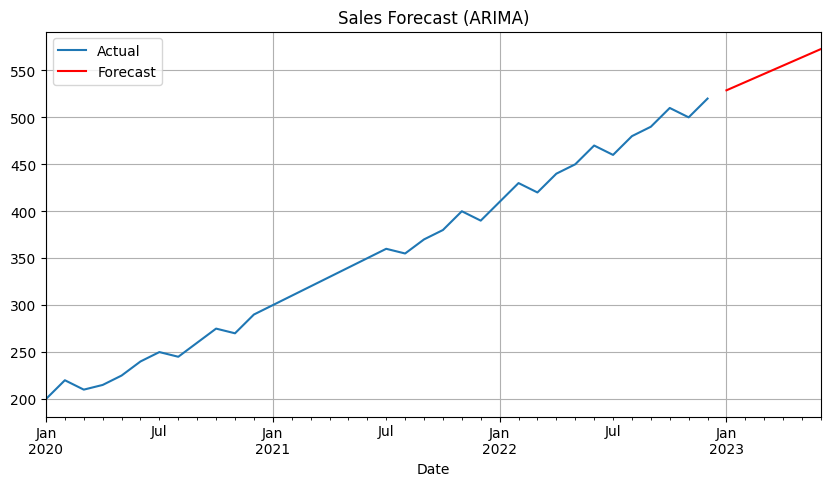

In [16]:
forecast = model_fit.forecast(steps=6)  # forecast next 6 months
print("Forecasted Sales:\n", forecast)

# Plot
df['Sales'].plot(label='Actual', figsize=(10, 5))
forecast.index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')
forecast.plot(label='Forecast', color='red')
plt.title("Sales Forecast (ARIMA)")
plt.legend()
plt.grid(True)
plt.show()


In [17]:
from sklearn.metrics import mean_squared_error

# mse = mean_squared_error(y_true, y_pred)
# rmse = np.sqrt(mse)
mse = mean_squared_error(df['Sales'][-6:], forecast)

In [18]:
!pip install yfinance matplotlib pandas



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📈 Scenario: Analyze and Visualize Stock Prices (e.g., Apple)

We'll use:

- **yfinance** to fetch stock data  
- **pandas** for data handling  
- **matplotlib** for plotting  
- A basic moving average strategy


In [30]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
import yfinance as yf

data = yf.download('MSFT', start='2022-01-01', end='2023-12-31')
data.to_csv("MSFT.csv")  # Save for offline use


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Empty DataFrame
Columns: [(Adj Close, MSFT), (Close, MSFT), (High, MSFT), (Low, MSFT), (Open, MSFT), (Volume, MSFT)]
Index: []


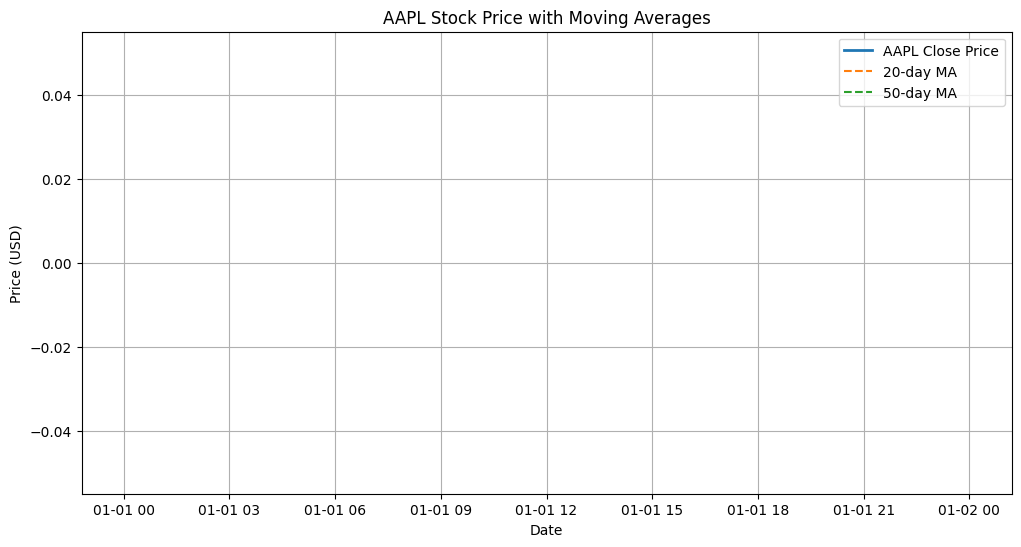

In [33]:


# Step 1: Download data
stock = yf.download('MSFT', start='2023-01-01', end='2023-12-31')  # Apple Inc.
print(stock.head())

# Step 2: Calculate Moving Averages
stock['MA20'] = stock['Close'].rolling(window=20).mean()   # 20-day MA
stock['MA50'] = stock['Close'].rolling(window=50).mean()   # 50-day MA

# Step 3: Plot the Closing Price and MAs
plt.figure(figsize=(12, 6))
plt.plot(stock['Close'], label='AAPL Close Price', linewidth=2)
plt.plot(stock['MA20'], label='20-day MA', linestyle='--')
plt.plot(stock['MA50'], label='50-day MA', linestyle='--')
plt.title("AAPL Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


### 📋 Variable Overview

This notebook uses several key variables for time series analysis and forecasting:

- **dates**:  
    A `DatetimeIndex` of 36 monthly periods from January 2020 to December 2022. Used as the time axis for the sales data.

- **df**:  
    A pandas DataFrame indexed by `Date`, containing a single column `Sales` with 36 monthly sales values. This is the main dataset for analysis and modeling.

- **sales**:  
    A Python list of 36 integer sales values, corresponding to the monthly sales in `df`.

- **model**:  
    An ARIMA model object (`statsmodels.tsa.arima.model.ARIMA`) fitted to the sales data. ARIMA is used for time series forecasting.

- **model_fit**:  
    The fitted ARIMA model results (`ARIMAResultsWrapper`). Contains estimated parameters and diagnostics.

- **forecast**:  
    A pandas Series with 6 forecasted sales values for the next 6 months (January–June 2023), generated by the ARIMA model.

- **mse**:  
    The mean squared error (MSE) between the last 6 actual sales values and the 6 forecasted values, used to evaluate forecast accuracy.

These variables enable data visualization, stationarity testing, ARIMA modeling, forecasting, and performance evaluation within the notebook.

In [22]:
# Step 4: Simple strategy - MA Crossover
stock['Signal'] = 0
stock.loc[stock['MA20'] > stock['MA50'], 'Signal'] = 1
stock.loc[stock['MA20'] < stock['MA50'], 'Signal'] = -1

# Show recent signals
print(stock[['Close', 'MA20', 'MA50', 'Signal']].tail())


Empty DataFrame
Columns: [(Close, AAPL), (MA20, ), (MA50, ), (Signal, )]
Index: []
